# NOTEBOOK: Hierarchical Clustering

 Goal: Implement and evaluate Hierarchical Clustering

## Setup

In [14]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader
from src.eda import (
    analyze_data
)
from src.preprocessing import DataPreprocessor
from src.models.unsupervised import SKLearnHierarchicalClustering
from src.models.unsupervised import SKLearnPCA

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load & Explore Data

In [15]:
X = data_loader.load_customer_segmentation()

analyze_data(X, show_stats=True)

DATA ANALYSIS

Dataset shape: 200 rows × 3 columns

Data types:
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

✓ No missing values found

Numerical columns (3):
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Categorical columns (0):
[]

Numerical features statistics:
              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000


{'numerical_cols': ['Age', 'Annual Income (k$)', 'Spending Score (1-100)'],
 'categorical_cols': [],
 'missing_summary': Empty DataFrame
 Columns: [Missing_Count, Missing_Percent]
 Index: []}

## Preprocess Data

In [16]:
preprocessor = DataPreprocessor(scale=True, encode_categorical=True) # Must scale for distance-based models
X_proc = preprocessor.fit_transform(X)


DataPreprocessor: fit_transform

1. Column types:
   Numerical: 3 columns
   Nominal categorical: 0 columns
   Ordinal categorical: 0 columns

2. Processing numerical columns...
   ✓ Applied median imputation

3. Processing nominal categorical columns...

4. Processing ordinal categorical columns...

6. Scaling features...
   ✓ Scaled 3 features

Final shape: 200 rows × 3 features



## Elbow Method - Find Optimal K


FINDING OPTIMAL NUMBER OF CLUSTERS
FINDING OPTIMAL NUMBER OF CLUSTERS

Testing k values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Method: both

k= 1: Inertia=  600.00
k= 2: Inertia=  400.00, Silhouette=0.3180
k= 3: Inertia=  316.72, Silhouette=0.3215
k= 4: Inertia=  234.24, Silhouette=0.3615
k= 5: Inertia=  186.81, Silhouette=0.3900
k= 6: Inertia=  139.58, Silhouette=0.4201
k= 7: Inertia=  126.26, Silhouette=0.3983
k= 8: Inertia=  113.11, Silhouette=0.3665
k= 9: Inertia=  101.34, Silhouette=0.3754
k=10: Inertia=   91.57, Silhouette=0.3809

💡 Elbow method suggests: k=4
💡 Silhouette method suggests: k=6 (score: 0.4201)

⚠️  Methods disagree (Elbow: k=4, Silhouette: k=6)
   → Recommending k=6 (Silhouette is more reliable)


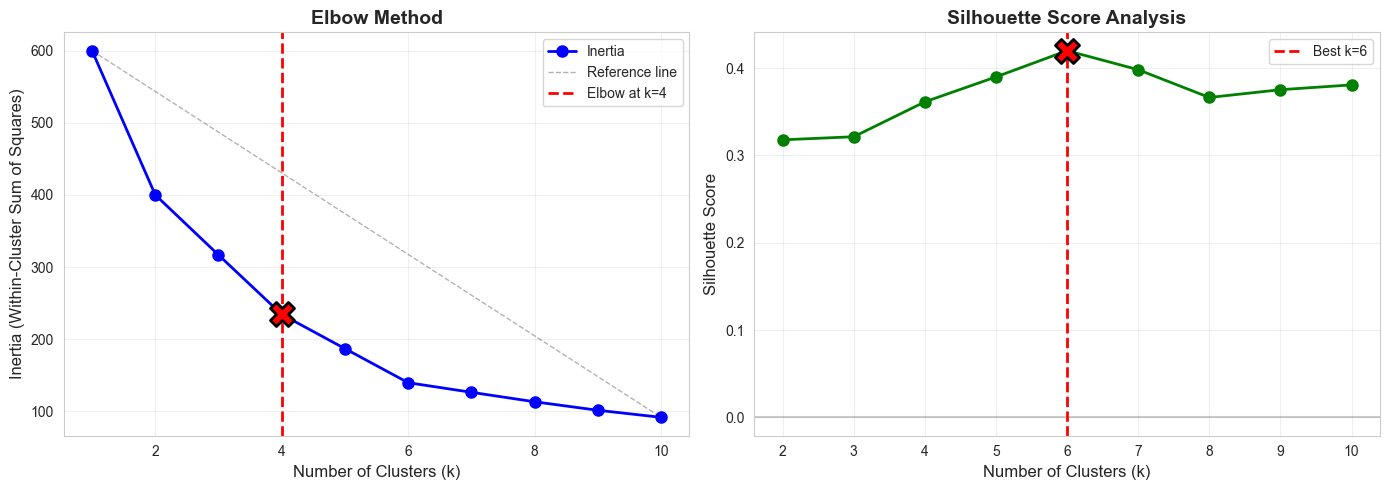


RECOMMENDED: k=6


In [17]:
print("\n" + "="*70)
print("FINDING OPTIMAL NUMBER OF CLUSTERS")
print("="*70)

# Create model (doesn't need k yet)
model = SKLearnHierarchicalClustering()

# Find optimal k automatically!
results = model.find_optimal_k(
    X_proc, 
    k_range=range(1, 11),
    method='both',  # Use both elbow and silhouette
    show_plot=True
)

# Get recommended k
optimal_k = results['optimal_k']

print(f"\n{'='*70}")
print(f"RECOMMENDED: k={optimal_k}")
print(f"{'='*70}")

## Dendrogram - Visualize Hierarchy

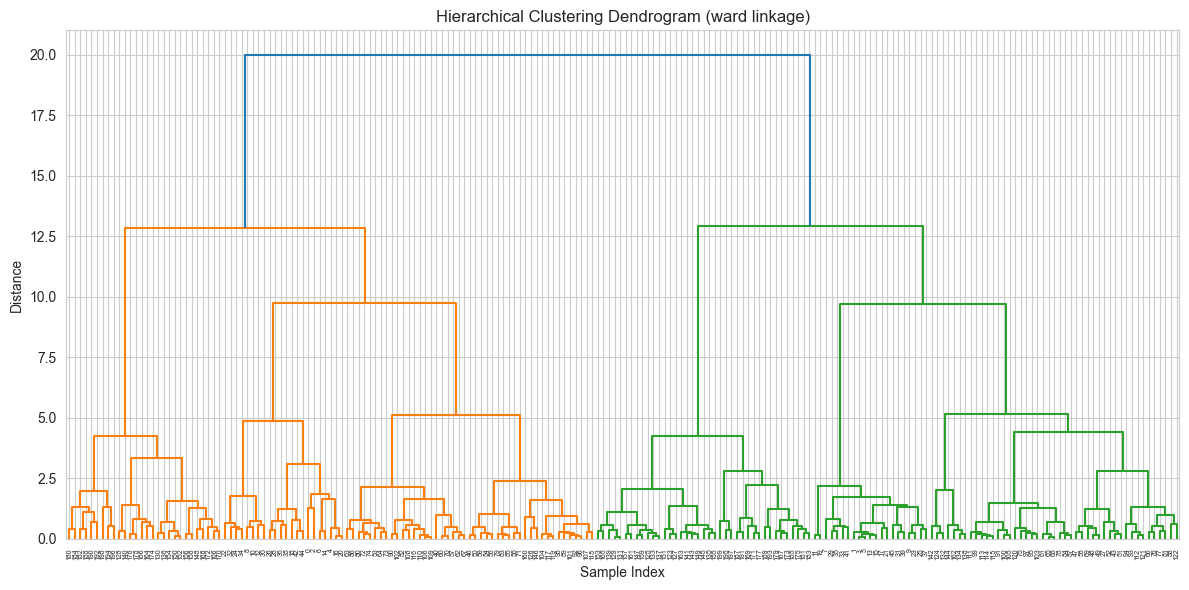

In [18]:
model.plot_dendrogram(X_proc)

## Train The Model With Optimal K

In [19]:
# Get recommended k
optimal_k = results['optimal_k']

print(f"\n{'='*70}")
print(f"RECOMMENDED: k={optimal_k}")
print(f"{'='*70}")

# Train final model with optimal k
print(f"\nTraining final model with k={optimal_k}...")
final_model = SKLearnHierarchicalClustering(n_clusters=optimal_k)
final_model.fit(X_proc)


RECOMMENDED: k=6

Training final model with k=6...


## Cluster Evaluation

In [20]:
print("\n" + "="*70)
print("CLUSTERING METRICS")
print("="*70)


# Silhouette Score (higher is better, range [-1, 1])
silhouette = final_model.silhouette_score(X_proc)
print(f"Silhouette Score: {silhouette:.4f}")
print("  • Range: [-1, 1]")
print("  • > 0.5: Good clustering")
print("  • 0.3-0.5: Acceptable")
print("  • < 0.3: Poor clustering")


CLUSTERING METRICS
Silhouette Score: 0.4201
  • Range: [-1, 1]
  • > 0.5: Good clustering
  • 0.3-0.5: Acceptable
  • < 0.3: Poor clustering


## Dimensionality Reduction Visualization


PCA 2D VISUALIZATION

PCA: CLUSTER VISUALIZATION
Number of clusters: 6
PCA explains 77.6% of variance


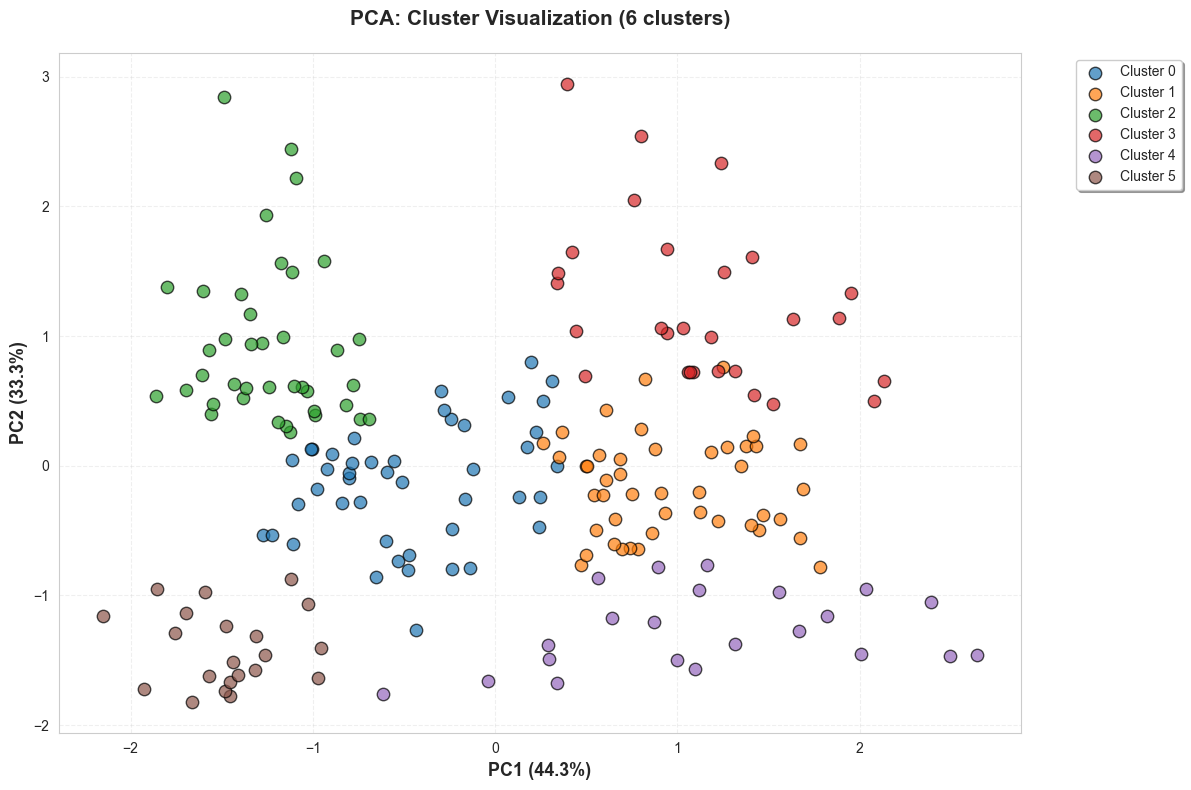


💡 Interpretation:
   • Each color = different cluster
   • Points close together = similar in feature space


In [26]:
print("\n" + "="*70)
print("PCA 2D VISUALIZATION")
print("="*70)

labels = final_model.predict(X_proc)
pca = SKLearnPCA(n_components=2)
pca.fit(X_proc)
pca.plot_clusters_2d(X_proc, labels)

## Silhouette Analysis


SILHOUETTE ANALYSIS
Overall Silhouette Score: 0.4201
Number of clusters: 6


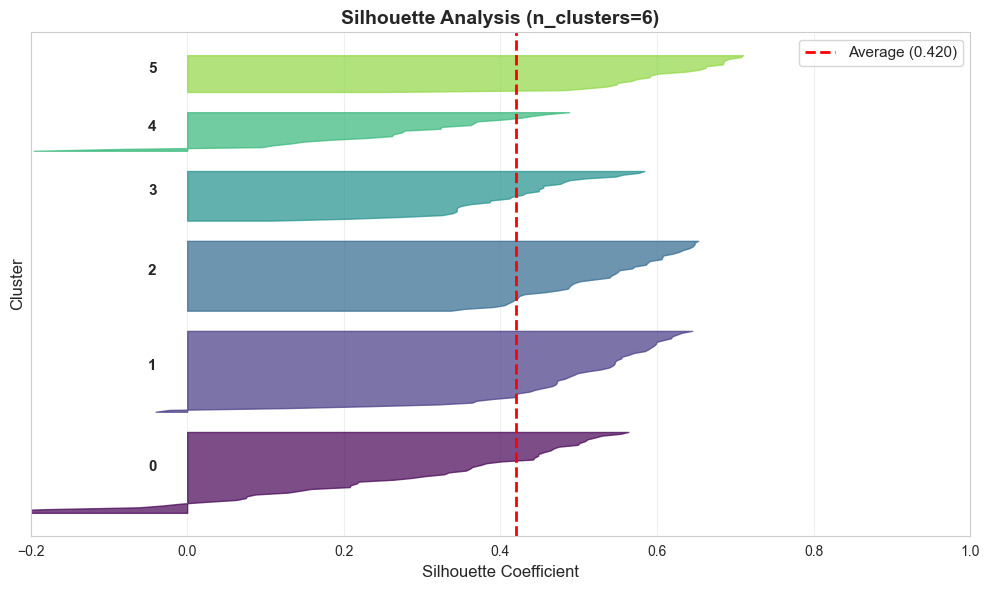


💡 How to interpret silhouette plot:
   • Width of silhouette = cluster size
   • Values > average (red line) = well-clustered samples
   • Negative values = samples likely in wrong cluster
   • Similar widths = balanced cluster sizes


In [30]:
final_model.plot_silhouette_analysis(X_proc)

## Linkage Method Comparison


COMPARING LINKAGE METHODS
ward      : Silhouette = 0.4201
complete  : Silhouette = 0.4201
average   : Silhouette = 0.4201
single    : Silhouette = 0.4201


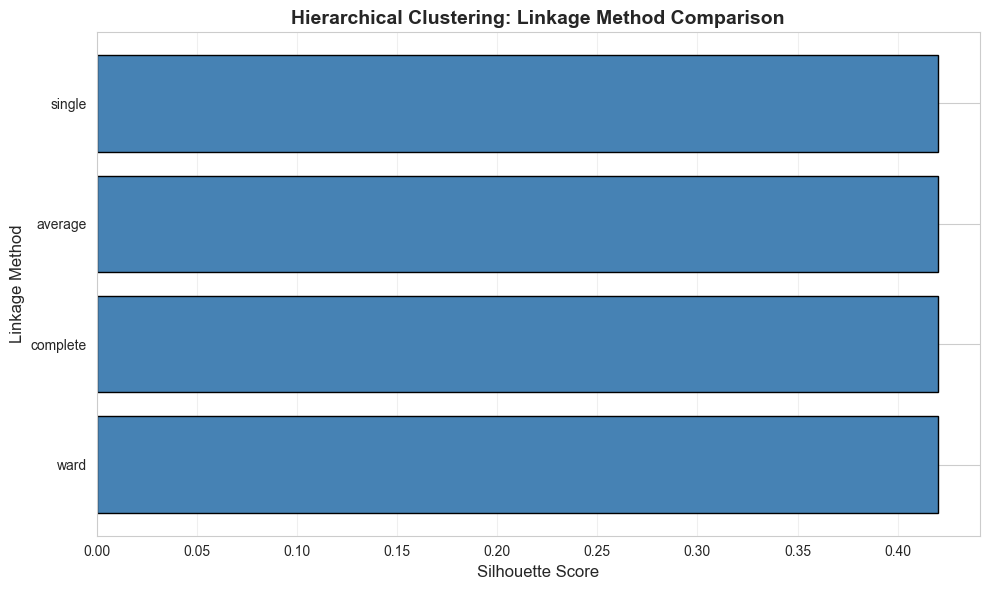


✓ Best linkage method: ward


In [27]:
print("\n" + "="*70)
print("COMPARING LINKAGE METHODS")
print("="*70)

linkage_methods = ['ward', 'complete', 'average', 'single']
linkage_scores = {}

for method in linkage_methods:
    temp_model = SKLearnHierarchicalClustering(
        n_clusters=optimal_k,
        linkage=method
    )
    temp_model.fit(X_proc)
    labels_temp = temp_model.predict(X_proc)
    
    score = final_model.silhouette_score(X_proc)
    linkage_scores[method] = score
    
    print(f"{method:10s}: Silhouette = {score:.4f}")

# Plot comparison
plt.figure(figsize=(10, 6))
methods = list(linkage_scores.keys())
scores = list(linkage_scores.values())

plt.barh(methods, scores, color='steelblue', edgecolor='black')
plt.xlabel('Silhouette Score', fontsize=12)
plt.ylabel('Linkage Method', fontsize=12)
plt.title('Hierarchical Clustering: Linkage Method Comparison',
         fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\n✓ Best linkage method: {max(linkage_scores, key=linkage_scores.get)}")

## Cluster Profiling


CLUSTER PROFILES

CLUSTER 0 (n=45)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  27.377778           57.511111               45.844444
std    7.758540           11.750478               14.108275

CLUSTER 1 (n=45)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  56.400000           55.288889               48.355556
std    8.373117            9.834129                6.869417

CLUSTER 2 (n=39)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  32.692308           86.538462               82.128205
std    3.728650           16.312485                9.364489

CLUSTER 3 (n=28)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  43.892857           91.285714               16.678571
std    8.337063           16.915601                8.973432

CLUSTER 4 (n=22)
            Age  Annual Income (k$)  Spending Score (1-100)
mean  44.318182           25.772727               20.272727
std   12.800247            7.646548               12

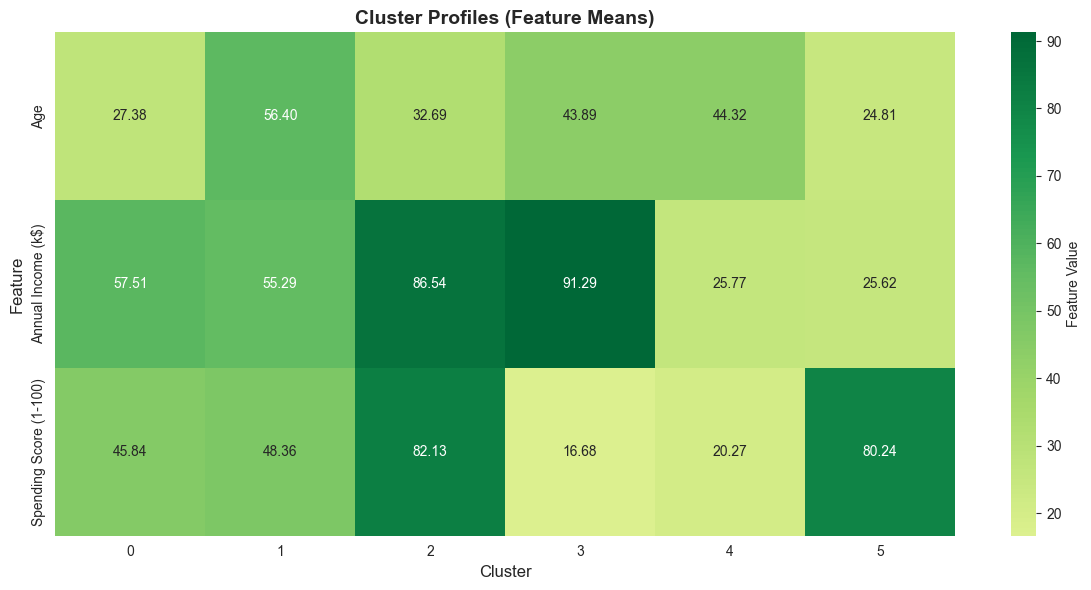


💡 Use cluster profiles to:
   • Name/interpret clusters (e.g., 'High income', 'Young users')
   • Understand what makes each cluster unique
   • Make business decisions based on cluster characteristics


In [28]:
print("\n" + "="*70)
print("CLUSTER PROFILES")
print("="*70)

# Add cluster labels to original data
X_clustered = X.copy()
X_clustered['Cluster'] = labels

# Profile each cluster
for cluster_id in range(optimal_k):
    cluster_data = X_clustered[X_clustered['Cluster'] == cluster_id]
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {cluster_id} (n={len(cluster_data)})")
    print(f"{'='*70}")
    print(cluster_data.drop('Cluster', axis=1).describe().loc[['mean', 'std']])

# Visualize cluster profiles
feature_cols = [col for col in X_clustered.columns if col != 'Cluster']
cluster_means = X_clustered.groupby('Cluster')[feature_cols].mean()

plt.figure(figsize=(12, 6))
sns.heatmap(cluster_means.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
           cbar_kws={'label': 'Feature Value'})
plt.title('Cluster Profiles (Feature Means)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\n💡 Use cluster profiles to:")
print("   • Name/interpret clusters (e.g., 'High income', 'Young users')")
print("   • Understand what makes each cluster unique")
print("   • Make business decisions based on cluster characteristics")

## Key Insights & Summary

In [29]:
print("\n" + "="*70)
print("KEY INSIGHTS")
print("="*70)

print(f"\n✓ Optimal clusters: {optimal_k}")
print(f"✓ Best linkage: {max(linkage_scores, key=linkage_scores.get)}")
print(f"✓ Silhouette Score: {silhouette:.4f}")

print(f"\n💡 Hierarchical Clustering:")
print(f"   • Builds cluster hierarchy (dendrogram)")
print(f"   • Can cut at any level for different K")
print(f"   • No need to specify K in advance")
print(f"   • Shows cluster relationships")

print(f"\n💡 When to use Hierarchical:")
print(f"   • Want to explore cluster hierarchy")
print(f"   • Number of clusters unknown")
print(f"   • Small to medium datasets")
print(f"   • Need interpretable cluster structure")

print(f"\n💡 Limitations:")
print(f"   • Computationally expensive (O(n²))")
print(f"   • Not suitable for large datasets")
print(f"   • Once merged, cannot undo")
print(f"   • Sensitive to noise and outliers")


KEY INSIGHTS

✓ Optimal clusters: 6
✓ Best linkage: ward
✓ Silhouette Score: 0.4201

💡 Hierarchical Clustering:
   • Builds cluster hierarchy (dendrogram)
   • Can cut at any level for different K
   • No need to specify K in advance
   • Shows cluster relationships

💡 When to use Hierarchical:
   • Want to explore cluster hierarchy
   • Number of clusters unknown
   • Small to medium datasets
   • Need interpretable cluster structure

💡 Limitations:
   • Computationally expensive (O(n²))
   • Not suitable for large datasets
   • Once merged, cannot undo
   • Sensitive to noise and outliers
